<a href="https://colab.research.google.com/github/AmanpreetKaur-123/Amanpreet-kaur/blob/main/Hotel_booking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HOTEL BOOKING

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objs as go
from plotly.offline import plot
import warnings
warnings.filterwarnings('ignore')

pd.set_option("display.max_columns", 36)

# Use seaborn styling properly
sns.set_theme()

# Custom styling
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titlesize"] = 25
plt.rcParams["axes.titleweight"] = 'bold'
plt.rcParams['xtick.labelsize']=15
plt.rcParams['ytick.labelsize']=15
plt.rcParams["axes.labelsize"] = 20
plt.rcParams["legend.fontsize"] = 15
plt.rcParams["legend.title_fontsize"] = 15

In [6]:
df = pd.read_csv('Hotel Bookings.csv')

In [7]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [9]:
# Dataset Rows & Columns count'
print('Number of rows : ',df.shape[0])
print('Number of columns : ',df.shape[1])

Number of rows :  119390
Number of columns :  32


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [11]:
# Dataset Duplicate Value Count
print('Total Number of duplicate values : ',df.duplicated().sum())
print(df.duplicated().value_counts())

Total Number of duplicate values :  31994
False    87396
True     31994
Name: count, dtype: int64


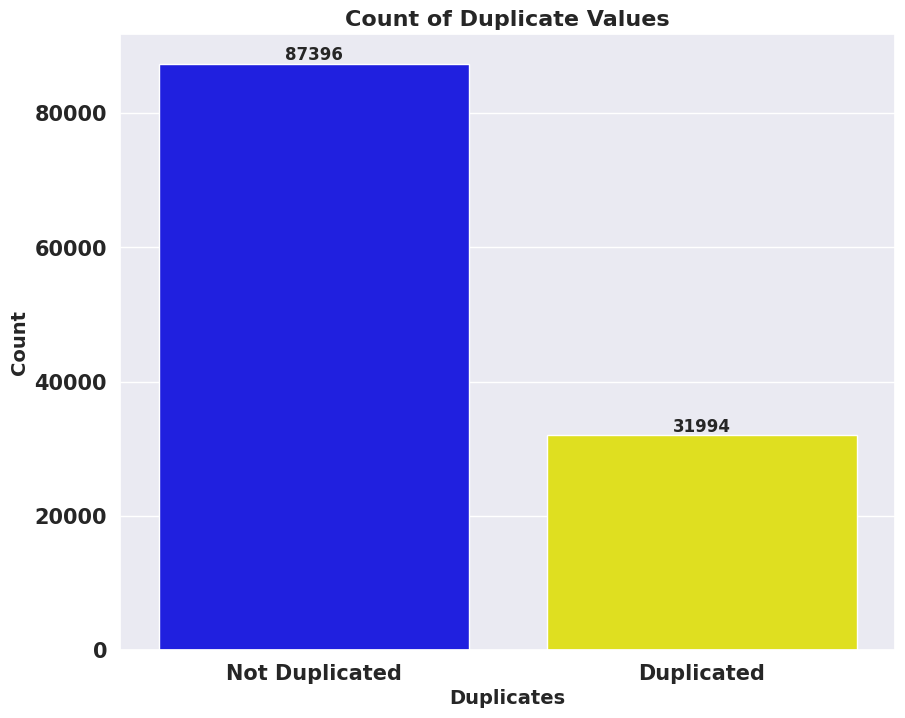

In [15]:
plt.figure(figsize=(10, 8))
sns.countplot(x=df.duplicated(), palette=['blue', 'yellow'])

for i, count in enumerate(df.duplicated().value_counts()):
    plt.text(i, count, str(count), ha='center', va='bottom', fontsize=12)

plt.title('Count of Duplicate Values', fontsize=16)
plt.xlabel('Duplicates', fontsize=14)
plt.ylabel('Count', fontsize=14)

plt.xticks(ticks=[0, 1], labels=['Not Duplicated', 'Duplicated'])

plt.show()

In [16]:
# Missing Values/Null Values Count
print("Total Number of null values : ",df.isnull().sum())

Total Number of null values :  hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                     

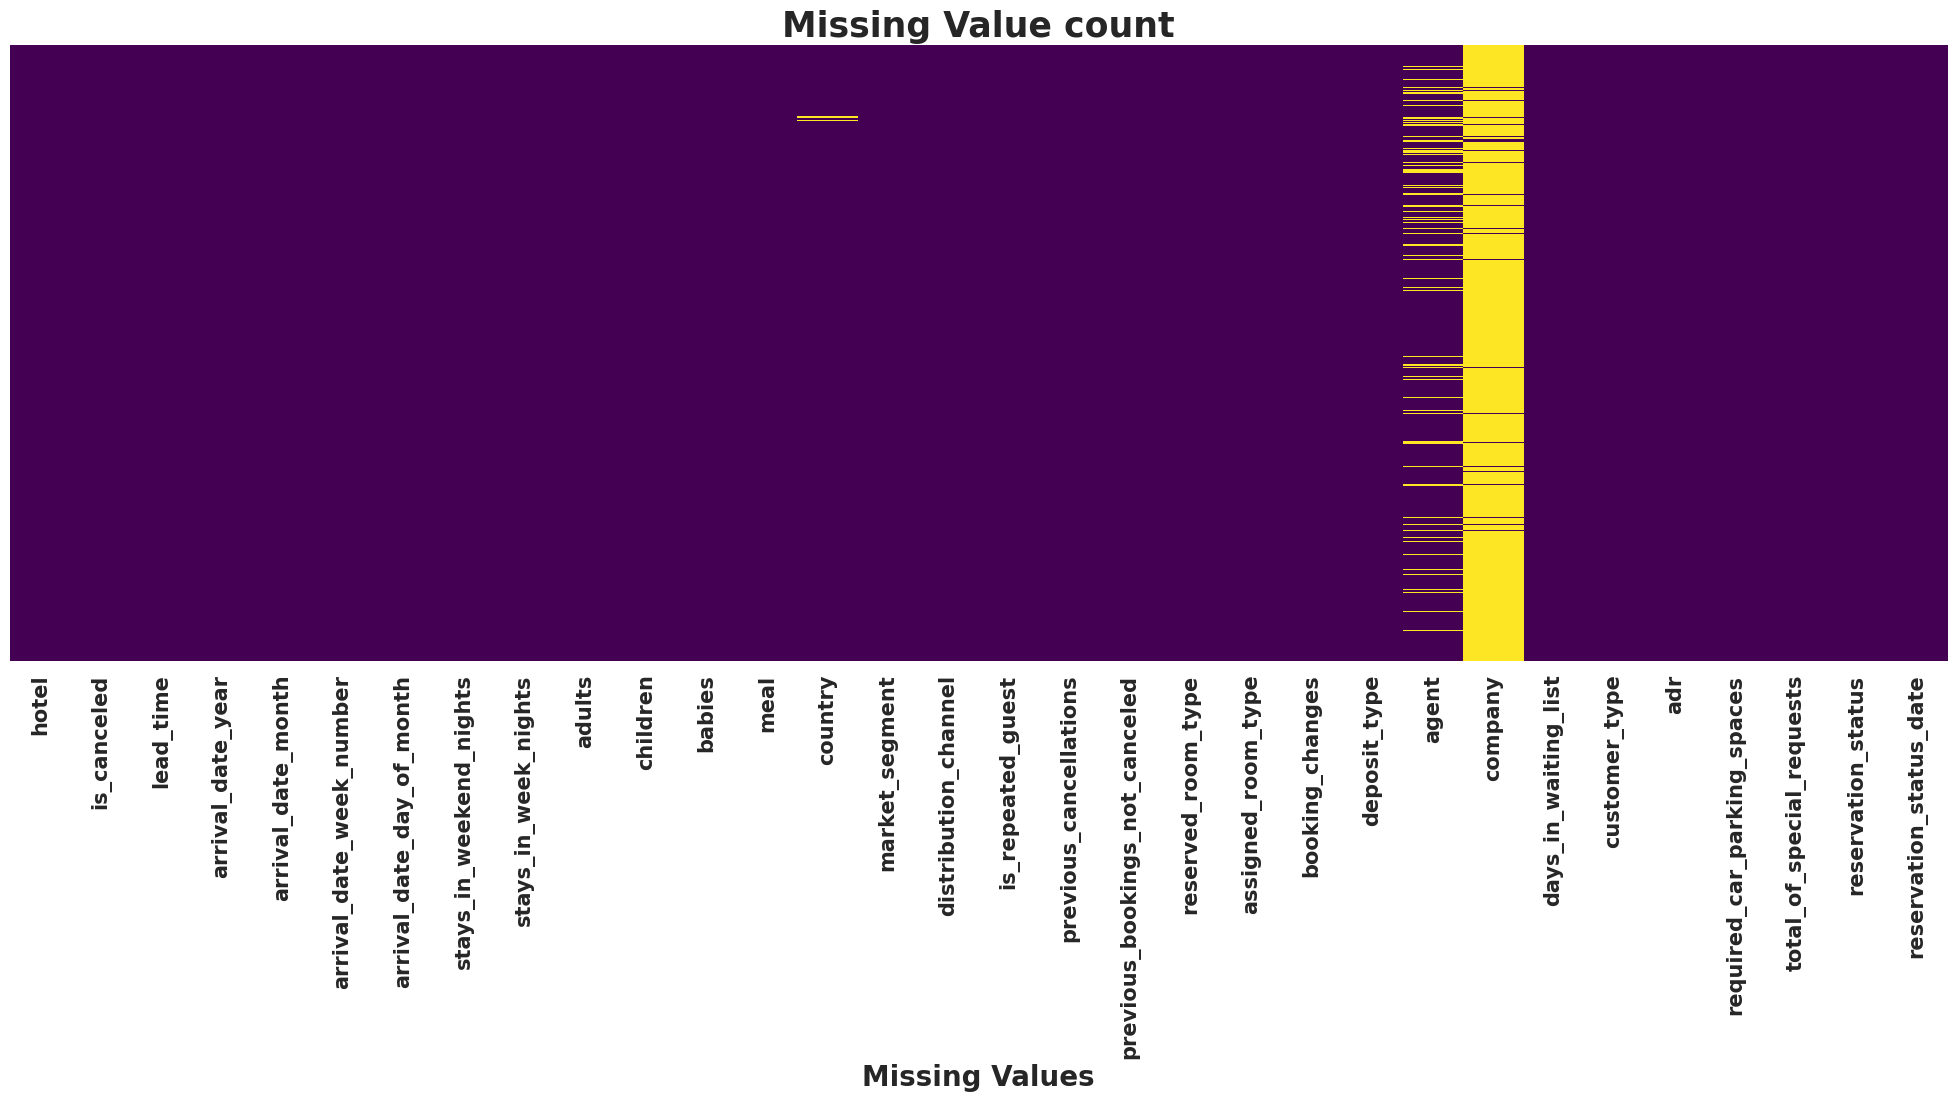

In [20]:
plt.figure(figsize=(25,8))
sns.heatmap(df.isnull(),cbar = False,yticklabels = False,cmap = 'viridis')
plt.xlabel('Missing Values')
plt.title('Missing Value count')
plt.show()

The dataset reveals distinct categories related to anomalies from a hotel's perspective, encompassing factors like company affiliation, lead time, distribution channels, and special guest requests—elements not typically observed. These insights signify significant shifts in prevailing conditions. Additionally, the dataset is characterized by an extensive array of rows and columns, punctuated by the presence of duplicate entries and missing values. Addressing these anomalies and discrepancies forms a critical component of our forthcoming data wrangling process

#Understanding the Variables

In [21]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [22]:
# Dataset Describe
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


Variables Description
1. hotel: Indicates the type of hotel booked (e.g., resort hotel or city hotel).
2. is_canceled: Variable indicating if the booking was canceled or not.
3. lead_time: Number of days between booking date and arrival date.
4. arrival_date_year: Year of arrival date.
5. arrival_date_month: Month of arrival date.
6. arrival_date_week_number: Week number of arrival date.
7. arrival_date_day_of_month: Day of arrival date.
8. stays_in_weekend_nights: Number of weekend nights booked.
9. stays_in_week_nights: Number of week nights booked.
10. adults: Number of adults.
11. children: Number of children.
12. babies: Number of babies.
13. meal: Type of meal booked (e.g., breakfast, half board, full board).
14. country: Country of origin of the guest.
15. market_segment: Market segment designation (e.g., online travel agencies, corporate).
16. distribution_channel: Booking distribution channel (e.g., travel agency, direct).
17. is_repeated_guest: Binary variable indicating if the booking is from a repeated guest (1) or not (0).
18. previous_cancellations: Number of previous bookings canceled by the customer.
19. previous_bookings_not_canceled: Number of previous bookings not canceled by the customer.
20. reserved_room_type: Type of room reserved.
assigned_room_type: Type of room assigned at check-in.
21. booking_changes: Number of changes made to the booking before arrival.
22. deposit_type: Type of deposit made (e.g., no deposit, refundable, non-refundable).
23. agent: ID of the travel agency that made the booking.
24. company: ID of the company or entity that made the booking.
25. days_in_waiting_list: Number of days the booking was in the waiting list before confirmed.
26. customer_type: Type of booking customer (e.g., transient, contract, group).
27. adr: Average daily rate (sum of all lodging transactions divided by the total number of staying nights).
28. required_car_parking_spaces: Number of car parking spaces required by the customer.
29. total_of_special_requests: Number of special requests made by the customer (e.g., late check-out, extra bed).
30. reservation_status: Reservation last status (e.g., checked-in, canceled).
31. reservation_status_date: Date at which the last status was set.

#Check Unique Values for each variable.

In [24]:
unique_values = {}

for column in df.columns:

    unique_values[column] = sorted(df[column].astype(str).unique())

for column, values in unique_values.items():
    print(f"Unique values for '{column}':")
    print(values)
    print()

Unique values for 'hotel':
['City Hotel', 'Resort Hotel']

Unique values for 'is_canceled':
['0', '1']

Unique values for 'lead_time':
['0', '1', '10', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '11', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '12', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '13', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '14', '140', '141', '142', '143', '144', '145', '146', '147', '148', '149', '15', '150', '151', '152', '153', '154', '155', '156', '157', '158', '159', '16', '160', '161', '162', '163', '164', '165', '166', '167', '168', '169', '17', '170', '171', '172', '173', '174', '175', '176', '177', '178', '179', '18', '180', '181', '182', '183', '184', '185', '186', '187', '188', '189', '19', '190', '191', '192', '193', '194', '195', '196', '197', '198', '199', '2', '20', '200', '201', '202', '203', '204', '205', '206', '207', '208', '209', '21', '210', 

Before commencing our data wrangling process, it's imperative to create a duplicate of our current dataset to document its original shape and to facilitate the comparison of any alterations made during the cleaning phase.

In [25]:
df1 = df.copy()

Data Wrangling

In [28]:
#Lets start with removing duplicate values
df1 = df1.drop_duplicates()
#From the above plot we can see that we have an ample amount of missing values in some of the columns of our dataset which needs to be handled
null_columns = ['agent','children','company']
for col in null_columns:
  df1[col].fillna(0,inplace = True)

df1['country'].fillna('others',inplace = True)

In [29]:
df1.isna().sum().sort_values(ascending=False).reset_index().rename(columns={'index':'Columns',0:'Null values'})

,Columns,Null values
0,hotel,0
1,is_canceled,0
2,lead_time,0
3,arrival_date_year,0
4,arrival_date_month,0
5,arrival_date_week_number,0
6,arrival_date_day_of_month,0
7,stays_in_weekend_nights,0
8,stays_in_week_nights,0
9,adults,0


In [31]:
len(df1[df1['adults']+df1['babies']+df1['children']==0])
df1.drop(df1[df1['adults']+df1['babies']+df1['children']==0].index,inplace = True)

Lets add some new columns to the dataset

In [32]:
df1['total_people'] = df1['adults']+df1['babies']+df1['children']
df1['total_stays'] = df1['stays_in_weekend_nights'] + df1['stays_in_week_nights']


In [33]:
df1['reserved_room_type'] = df1['reserved_room_type'].replace({
    'A': 'Single Room',
    'B': 'Double Room',
    'C': 'Twin Room',
    'D': 'Triple Room',
    'E': 'Quad Room',
    'F': 'Queen Room',
    'G': 'King Room',
    'H': 'Studio Room',
    'L': 'Deluxe Room'
})

In [34]:
df1['total_of_special_requests'].unique()
df1['total_of_special_requests'] = df1['total_of_special_requests'].replace({0:'Early Check-in',1:'Late Check-out',2:'Room Preference',3:'Extra Bed or Cot',4:'Special Amenities',5:'Room Upgrades'})


Lets see what new information we derive from our dataset

In [35]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 87230 entries, 0 to 119389
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87230 non-null  object 
 1   is_canceled                     87230 non-null  int64  
 2   lead_time                       87230 non-null  int64  
 3   arrival_date_year               87230 non-null  int64  
 4   arrival_date_month              87230 non-null  object 
 5   arrival_date_week_number        87230 non-null  int64  
 6   arrival_date_day_of_month       87230 non-null  int64  
 7   stays_in_weekend_nights         87230 non-null  int64  
 8   stays_in_week_nights            87230 non-null  int64  
 9   adults                          87230 non-null  int64  
 10  children                        87230 non-null  float64
 11  babies                          87230 non-null  int64  
 12  meal                            8723

Once we have completed our Data Cleaning lets see the diffrence between our old and new dataset

In [36]:
print('Number of rows in the dataset : ',df.shape[0])
print('Number of cols in the dataset : ',df.shape[1])

print('Number of rows in the N_dataset : ',df1.shape[0])
print('Number of cols in the N_dataset : ',df1.shape[1])

diff_rows = ((df.shape[0] - df1.shape[0]))
diff_cols = ((df1.shape[1] - df.shape[1]))

print("difference in rows:", diff_rows)
print("difference in columns:", diff_cols)

Number of rows in the dataset :  87396
Number of cols in the dataset :  32
Number of rows in the N_dataset :  87230
Number of cols in the N_dataset :  34
difference in rows: 166
difference in columns: 2


#What all manipulations have you done and insights you found?
Upon inspecting the dataset, it became evident that certain anomalies were present, necessitating data transformation. As part of the basic data cleaning process, we took measures to remove redundant or irrelevant data points. Additionally, it was observed that some constraints within the dataset exhibited disparate distributions. To address this, we aggregated these constraints and created new columns, which proved instrumental for subsequent visualization tasks. This process not only enhanced the dataset's coherence but also facilitated more insightful exploratory analysis.

4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables
* Which type of hotel is most frequently chosen by customers?

In [39]:
hotel_counts = df1['hotel'].value_counts()

# Create the pie chart
fig = px.pie(hotel_counts,
             values=hotel_counts.values,
             names=hotel_counts.index,
             title='Distribution of Hotel Types Preferred by Customers',
             hole=0.1)

# Update chart layout
fig.update_traces(textinfo='percent+label', pull=[0.05, 0.05], showlegend=False)

fig.update_layout(font_size=20,
                  height=600,
                  width=800,
                  title=dict(x=0.5, y=0.95, xanchor='center', yanchor='top'),
                  paper_bgcolor='#E1F8DC',
                  plot_bgcolor='#CAF1DE')

# Show the plot
fig.show()

2. What is/are the insight(s) found from the chart?
To kick-start our analysis on the specific needs of our customers, we conducted a univariate analysis on the hotel type. The results revealed that the majority of customers prefer City Hotels over Resort Hotels.

* City Hotel:
Located in urban areas, catering primarily to business travelers with essential amenities like Wi-Fi and meeting rooms.
Resort Hotel:
Situated in vacation destinations, offering extensive recreational facilities for leisure travelers.
3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.
We observed that 61% of our customers prefer city hotels over resorts. This is positive for our business, but it doesn't mean we should neglect the resort segment. While resort hotels are performing well, they require certain improvements to meet customer needs better, which we will address in due course.

# Booking Analysis
* What are the booking trends over time? Are there any seasonal patterns?

In [40]:
city_hotel = df1[df1['hotel'] == 'City Hotel']
resort_hotel = df1[df1['hotel'] == 'Resort Hotel']

city_max_bookings = city_hotel[city_hotel['is_canceled'] == 'Not Cancelled'].groupby('arrival_date_year')['arrival_date_year'].count().reset_index(name='Maximum Bookings')
resort_max_bookings = resort_hotel[resort_hotel['is_canceled'] == 'Not Cancelled'].groupby('arrival_date_year')['arrival_date_year'].count().reset_index(name='Maximum Bookings')

merged_data = city_max_bookings.merge(resort_max_bookings, on='arrival_date_year', suffixes=('_city', '_resort'))

fig = px.area(merged_data, x='arrival_date_year', y=['Maximum Bookings_city', 'Maximum Bookings_resort'],
              title='Maximum Bookings Over Time for City Hotel and Resort Hotel By Year',
             labels={'arrival_date_month': 'Month', 'value': 'Maximum Bookings', 'variable': 'Hotel Type'},
              color_discrete_map={'Maximum Bookings_city': '#EE2225', 'Maximum Bookings_resort': '#F69E1D'})

fig.update_layout(title=dict(x=0.5, y=0.95, xanchor='center', yanchor='top'),
                  paper_bgcolor='#CAF1DE',
                  plot_bgcolor='#E1F8DC',
                  xaxis=dict(showgrid=False),
                  yaxis=dict(showgrid=False))
fig.show()

In [41]:
city_hotel = df1[df1['hotel'] == 'City Hotel']
resort_hotel = df1[df1['hotel'] == 'Resort Hotel']

city_max_bookings = city_hotel[city_hotel['is_canceled'] == 'Not Cancelled'].groupby(['arrival_date_month', 'is_canceled'])['arrival_date_month'].count().reset_index(name='Maximum Bookings')
resort_max_bookings = resort_hotel[resort_hotel['is_canceled'] == 'Not Cancelled'].groupby(['arrival_date_month', 'is_canceled'])['arrival_date_month'].count().reset_index(name='Maximum Bookings')

merged_data = city_max_bookings.merge(resort_max_bookings, on='arrival_date_month', suffixes=('_city', '_resort'))

fig = px.bar(merged_data, x='arrival_date_month', y=['Maximum Bookings_city', 'Maximum Bookings_resort'],
             title='Maximum Bookings Over Time for City Hoteland Resort Hotel By Season',
             labels={'arrival_date_month': 'Month', 'value': 'Maximum Bookings', 'variable': 'Hotel Type'},
             color_discrete_map={'Maximum Bookings_city': '#814FA0', 'Maximum Bookings_resort': '#347FC2'})

fig.update_layout(title=dict(x=0.5, y=0.95, xanchor='center', yanchor='top'),
                  paper_bgcolor='#CAF1DE',
                  plot_bgcolor='#E1F8DC',
                  xaxis=dict(showgrid=False,gridcolor = 'black'),
                  yaxis=dict(showgrid=False,gridcolor = 'black'))


fig.show()

How do booking trends differ between weekdays and weekends

In [44]:
# Filter the DataFrame for each hotel type
city_hotel = df1[df1['hotel'] == 'City Hotel']
resort_hotel = df1[df1['hotel'] == 'Resort Hotel']

city_weekend = city_hotel[city_hotel['is_canceled'] == 'Not Cancelled']['stays_in_weekend_nights'].sum()
city_week = city_hotel[city_hotel['is_canceled'] == 'Not Cancelled']['stays_in_week_nights'].sum()
resort_weekend = resort_hotel[resort_hotel['is_canceled'] == 'Not Cancelled']['stays_in_weekend_nights'].sum()
resort_week = resort_hotel[resort_hotel['is_canceled'] == 'Not Cancelled']['stays_in_week_nights'].sum()


data = {
    'Period': ['Weekend', 'Weekend', 'Weekday', 'Weekday'],
    'Total Stays': [city_weekend, resort_weekend, city_week, resort_week],
    'Hotel Type': ['City Hotel', 'Resort Hotel', 'City Hotel', 'Resort Hotel']
}
df2 = pd.DataFrame(data)

# Create the stacked bar plot
fig = px.bar(df2, x='Period', y='Total Stays', color='Hotel Type',
             title='Total Stays During Weekends and Weekdays',
             labels={'Period': 'Period', 'Total Stays': 'Total Stays'},
             color_discrete_sequence=['#19AC5B', '#F69E1D'])

# Customize layout
fig.update_layout(title=dict(x=0.5, y=0.95, xanchor='center', yanchor='top'),
                  paper_bgcolor='#CAF1DE',
                  plot_bgcolor='#E1F8DC',
                  xaxis=dict(showgrid=False,gridcolor = 'black'),
                  yaxis=dict(showgrid=False,gridcolor = 'black'))

# Show the plot
fig.show()

Which agent made most booking

In [45]:
# Group by 'hotel' and 'agent' and count the number of bookings per agent
highest_booking = df1.groupby(['hotel', 'agent'])['agent'].agg({'count'}).reset_index().rename(columns={'count': 'Most Bookings'}).sort_values(by='Most Bookings', ascending=False)

# Drop rows where 'agent' is 0 (assuming 0 is an invalid or placeholder value)
highest_booking.drop(highest_booking[highest_booking['agent'] == 0].index, inplace=True)

# Filter for each hotel type
city_hotel_bookings = highest_booking[highest_booking['hotel'] == 'City Hotel']
resort_hotel_bookings = highest_booking[highest_booking['hotel'] == 'Resort Hotel']

# Select the top agents for each hotel type
top_agents_limit = 5
top_city_agents = city_hotel_bookings.sort_values(by='Most Bookings', ascending=False).head(top_agents_limit)
top_resort_agents = resort_hotel_bookings.sort_values(by='Most Bookings', ascending=False).head(top_agents_limit)

# Combine the top agents data into one DataFrame
top_agents_combined = pd.concat([top_city_agents, top_resort_agents])

# Create the grouped bar chart
fig = px.bar(top_agents_combined,
             x='agent',
             y='Most Bookings',
             color='hotel',
             barmode='group',
             text='Most Bookings',
             title='Most Bookings By Top Agents',
             labels={'agent': 'Agent', 'Most Bookings': 'Number of Bookings', 'hotel': 'Hotel Type'},
             height=600, width=1200)

# Update traces for text position and bar width
fig.update_traces(textposition='inside', width=6.8)

# Update layout for title, background color, and grid lines
fig.update_layout(
    title={
        'text': 'Most Bookings By Top Agents',
        'y':0.9,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top',
    },
    plot_bgcolor='#E1F8DC',
    paper_bgcolor='#CAF1DE',
    xaxis_showgrid=False,
    yaxis_showgrid=False,
    xaxis_gridcolor='black',
    yaxis_gridcolor='black',)

# Show the plot
fig.show()



**Insights**

Based on the booking trends, we can clearly see a significant spike in bookings between 2015 and 2016, followed by a gradual decrease between 2016 and 2017. This fluctuation could be attributed to various events or factors specific to those years.

Furthermore, an analysis of monthly booking patterns reveals that the highest number of bookings occurred from May to August, which aligns with the peak summer season. This seasonal trend is consistent with increased travel and vacation activities during this period.

When comparing bookings made on weekdays versus weekends, the data shows a substantial difference. Approximately 30,000 bookings were made on weekdays, while weekends saw about 80,000 bookings for both city and resort destinations.

Lastly, an evaluation of our agents' performance revealed that Agent 9 made an impressive 28,000 bookings, significantly outpacing Agent 240, who made 13,000 bookings for resorts. This indicates a notable difference in performance among our agents.

**Customer Demographics**

What are the demographics of the customers (e.g., age, gender, nationality)?

In [46]:
df1['adults'] = df1['adults'].astype(int)
df1['children'] = df1['children'].astype(int)


guests_demo = df1.groupby('country')[['adults', 'children', 'babies']].sum().reset_index()
guests_demo['total_guests'] = guests_demo['adults'] + guests_demo['children'] + guests_demo['babies']


top_ten_countries = guests_demo.sort_values(by='total_guests', ascending=False).head(10)


top_ten_countries_melted = top_ten_countries.melt(id_vars='country', value_vars=['adults', 'children', 'babies'],
                                                  var_name='Guest Type', value_name='Count')


fig = px.bar(top_ten_countries_melted,
             x='country',
             y='Count',
             color='Guest Type',
             title='Number of Adults, Children, and Babies in Top 10 Countries',
             labels={'country': 'Country', 'Count': 'Number of Guests', 'Guest Type': 'Guest Type'},
             height=600, width=1000,
             color_discrete_sequence=['#EE2225', '#F69E1D', '#19AC5B'])


fig.update_layout(title=dict(x=0.5, y=0.95, xanchor='center', yanchor='top'),
                  paper_bgcolor='#CAF1DE',
                  plot_bgcolor='#E1F8DC',
                  xaxis=dict(showgrid=False),
                  yaxis=dict(showgrid=False),
                  title_font=dict(size=20, family="Arial"))


fig.show()

What are Types of Customers?

In [47]:
customer_type_counts = df1['customer_type'].value_counts().reset_index()
customer_type_counts.columns = ['customer_type', 'count']

# Create the pie chart
fig = px.pie(customer_type_counts,
             names='customer_type',
             values='count',
             title='Distribution of Customer Types',
             hole=0.1)

# Update traces for the pie chart
fig.update_traces(textinfo='percent+label', pull=[0.05] * len(customer_type_counts), showlegend=False)

# Update layout to customize background and title
fig.update_layout(font_size=20,
                  height=600,
                  width=800,
                  title=dict(x=0.5, y=0.95, xanchor='center', yanchor='top'),
                  paper_bgcolor='#CAF1DE',  # Background color for the entire plot area
                  plot_bgcolor='#CAF1DE',  # Background color for the plot area
                  title_font=dict(size=24, family="Arial"))  # Title font customization

# Show the plot
fig.show()

What is the Percentage of repeated Guest?

In [48]:
df1['is_repeated_guest'] = df1['is_repeated_guest'].replace({0: 'New Guests', 1: 'Repeated Guests'})

# Calculate value counts for repeated guests
hotel_rep_guest = df1['is_repeated_guest'].value_counts()


fig = px.pie(hotel_rep_guest,
             values=hotel_rep_guest.values,
             names=hotel_rep_guest.index,
             title='Percentage of Repeated Guests',
             hole=0.3)


fig.update_traces(textinfo='percent+label', pull=[0.05, 0.05], showlegend=False)


fig.update_layout(font_size=20,
                  height=600,
                  width=800,
                  title=dict(x=0.5, y=0.95, xanchor='center', yanchor='top'),
                  paper_bgcolor='#CAF1DE',
                  plot_bgcolor='#CAF1DE',
                  title_font=dict(size=24, family="Arial"))

# Show the plot
fig.show()


**Insights**

One of the main objectives of this analysis was to understand customer demographics. After a thorough analysis, we found that the majority of guests traveled from Portugal, followed by the UK and France. This insight provides a clear direction on prioritizing our marketing efforts towards these countries to enhance business growth.

Additionally, we examined the distribution of customer types. Transient customers accounted for a high volume of bookings at 82%, followed by Transient Party customers at 13%. This information helps us focus our marketing strategies on the most significant customer segments.

Moreover, the data indicates that new guests have a higher booking rate compared to repeat guests. This highlights a potential area of neglect towards our existing customers, suggesting a need for strategies to improve customer retention alongside attracting new guests.

**Customer Preferences**

Which room types are most preferred by customers?

In [49]:
# Filter the DataFrame for each hotel type
city_hotel = df1[df1['hotel'] == 'City Hotel']
resort_hotel = df1[df1['hotel'] == 'Resort Hotel']

# Group by customer type and reserved room type
room_type_city = city_hotel.groupby('customer_type')['reserved_room_type'].value_counts().reset_index()
room_type_resort = resort_hotel.groupby('customer_type')['reserved_room_type'].value_counts().reset_index()

# Create the bar chart for city hotel
fig_city = px.bar(room_type_city, x='reserved_room_type', y='count', color='customer_type',
             title='Counts of Reserved Room Types by Customer Type - City Hotel',
             labels={'reserved_room_type': 'Room Type', 'count': 'Count', 'customer_type': 'Customer Type'},
             barmode='stack')

# Create the bar chart for resort hotel
fig_resort = px.bar(room_type_resort, x='reserved_room_type', y='count', color='customer_type',
             title='Counts of Reserved Room Types by Customer Type - Resort Hotel',
             labels={'reserved_room_type': 'Room Type', 'count': 'Count', 'customer_type': 'Customer Type'},
             barmode='stack')

# Function to customize layout
def customize_layout(fig):
    fig.update_layout(
        title=dict(x=0.5, y=0.95, xanchor='center', yanchor='top'),  # Centered title
        paper_bgcolor='#CAF1DE',  # Background color for the entire plot area
        plot_bgcolor='#E1F8DC',  # Background color for the plot area
        xaxis=dict(showgrid=False),  # Remove x-axis grid lines
        yaxis=dict(showgrid=False)  # Remove y-axis grid lines
    )

# Apply layout customization to both figures
customize_layout(fig_city)
customize_layout(fig_resort)

# Show the plots
fig_city.show()
fig_resort.show()

What are the most common special requests made by customers (e.g., early check-in, late check-out)?

In [50]:
# Filter the DataFrame for each hotel type
city_hotel = df1[df1['hotel'] == 'City Hotel']
resort_hotel = df1[df1['hotel'] == 'Resort Hotel']

# Group by customer type and total special requests for city hotel
special_requests_city = city_hotel.groupby(['customer_type', 'total_of_special_requests']).size().reset_index(name='count')

# Group by customer type and total special requests for resort hotel
special_requests_resort = resort_hotel.groupby(['customer_type', 'total_of_special_requests']).size().reset_index(name='count')

# Function to customize layout
def customize_layout(fig):
    fig.update_layout(
        title=dict(x=0.5, y=0.95, xanchor='center', yanchor='top'),  # Centered title
        paper_bgcolor='#CAF1DE',  # Background color for the entire plot area
        plot_bgcolor='#E1F8DC',  # Background color for the plot area
        xaxis=dict(showgrid=False),  # Remove x-axis grid lines
        yaxis=dict(showgrid=False)  # Remove y-axis grid lines
    )

# Create a grouped bar chart for city hotel
fig_city = px.bar(special_requests_city, x='total_of_special_requests', y='count', color='customer_type',
             title='Counts of Special Requests by Customer Type - City Hotel',
             labels={'total_of_special_requests': 'Special Requests', 'count': 'Count', 'customer_type': 'Customer Type'},
             barmode='group')

# Create a grouped bar chart for resort hotel
fig_resort = px.bar(special_requests_resort, x='total_of_special_requests', y='count', color='customer_type',
             title='Counts of Special Requests by Customer Type - Resort Hotel',
             labels={'total_of_special_requests': 'Special Requests', 'count': 'Count', 'customer_type': 'Customer Type'},
             barmode='group')

# Apply layout customization to both figures
customize_layout(fig_city)
customize_layout(fig_resort)

# Show the plots
fig_city.show()
fig_resort.show()

**Insights**

When initiating our analysis, we encountered several constraints pertinent to hotel bookings. Among these, customer preferences emerged as a significant factor. Our analysis revealed that a substantial portion of preferences leaned towards single-room accommodations. Approximately 40,000 bookings were observed for city-type hotels, whereas resort-type hotels accounted for around 17,000 bookings in this category.

Furthermore, our investigation unearthed a prevalent customer request, indicating a distinct inclination towards early check-in and late check-out options. This preference aligns with the desire for added flexibility and convenience during their stay, showcasing the importance of accommodating such requests to enhance overall guest satisfaction and experience.

**Cancellation Analysis**

What is the percentage of cancellation

In [51]:
df1['is_canceled'] = df1['is_canceled'].replace({0: 'Not Cancelled', 1: 'Cancelled'})

hotel_can = df1['is_canceled'].value_counts()

fig = px.pie(hotel_can,
             values=hotel_can.values,
             names=hotel_can.index,
             title='Cancellation Percentage')

fig.update_traces(textinfo='percent+label', pull=[0.05, 0.05], showlegend=False)

fig.update_layout(font_size=20,
                  height=600,
                  width=800,
                  title=dict(x=0.5, y=0.95, xanchor='center', yanchor='top'),
                  paper_bgcolor='#CAF1DE',
                  plot_bgcolor='#CAF1DE')

fig.show()

What is the cancellation rate, and how does it vary across different factors (e.g., booking lead time, room type)?

In [52]:
df1['is_cancelled_copy'] = df1['is_canceled'].map({'Not Cancelled': 0, 'Cancelled': 1})


lead_time_cancellation = df1.groupby('lead_time')['is_cancelled_copy'].mean().reset_index()
lead_time_cancellation.columns = ['lead_time', 'cancellation_rate']


room_type_cancellation = df1.groupby('reserved_room_type')['is_cancelled_copy'].mean().reset_index()
room_type_cancellation.columns = ['reserved_room_type', 'cancellation_rate']


combined_cancellation = df1.groupby(['lead_time', 'reserved_room_type'])['is_cancelled_copy'].mean().reset_index()
combined_cancellation.columns = ['lead_time', 'reserved_room_type', 'cancellation_rate']

fig = px.scatter(combined_cancellation,
                 x='lead_time',
                 y='cancellation_rate',
                 color='reserved_room_type',
                 title='Cancellation Rate Over Booking Lead Time by Room Type',
                )

fig.update_layout(title=dict(x=0.5, y=0.95, xanchor='center', yanchor='top'),
                  paper_bgcolor='#CAF1DE',
                  plot_bgcolor='#CAF1DE',
                  xaxis=dict(showgrid=False),
                  yaxis=dict(showgrid=False),
                  title_font=dict(size=24, family="Arial"))

fig.show()

**Insights**

One of the major concerns in the hotel industry is cancellations, which can significantly impact operations. After conducting a thorough analysis, we found that the cancellation rate is currently 27%, which is an improvement compared to previous years. An interesting insight from our analysis is that cancellations are more frequent for Single rooms, particularly when the lead time (the time between booking and the stay) ranges from 100 to 400 days.

**Revenue Analysis**

What is the average daily rate (ADR) and revenue per available room (RevPAR)

In [53]:
total_room_revenue = df1['adr'] * (df1['stays_in_weekend_nights'] + df1['stays_in_week_nights'])
total_rooms_sold = df1['is_cancelled_copy'].value_counts().get(0, 0)
total_available_rooms = df1['reserved_room_type'].value_counts().sum()
adr = int(total_room_revenue.sum() / total_rooms_sold)
revpar = int(total_room_revenue.sum() / total_available_rooms)


metrics = ['ADR', 'RevPAR']
values = [adr, revpar]

fig = go.Figure(go.Bar(
    x=metrics,
    y=values,
    text=values,
    textposition='auto',
    marker=dict(color=['blue', 'green'])
))


fig.update_layout(
    title=dict(
        text='Average Daily Rate (ADR) and Revenue per Available Room (RevPAR)',
        x=0.5,
        y=0.95,
        xanchor='center',
        yanchor='top'
    ),
    xaxis_title='Metric',
    yaxis_title='Value',
    paper_bgcolor='#CAF1DE',
    plot_bgcolor='#E1F8DC',
    xaxis=dict(showgrid=False),
    yaxis=dict(showgrid=False)
)

# Show the plot
fig.show()

How does revenue vary across different room types, customer segments

In [54]:
df1['total_room_revenue'] = df1['adr'] * (df1['stays_in_weekend_nights'] + df1['stays_in_week_nights'])

In [55]:
city_hotel = df1[df1['hotel'] == 'City Hotel']
resort_hotel = df1[df1['hotel'] == 'Resort Hotel']

room_type_revenue_city = city_hotel.groupby('reserved_room_type')['total_room_revenue'].sum().reset_index()
customer_segment_revenue_city = city_hotel.groupby('customer_type')['total_room_revenue'].sum().reset_index()

room_type_revenue_resort = resort_hotel.groupby('reserved_room_type')['total_room_revenue'].sum().reset_index()
customer_segment_revenue_resort = resort_hotel.groupby('customer_type')['total_room_revenue'].sum().reset_index()

# Convert total room revenue to integers
room_type_revenue_city['total_room_revenue'] = room_type_revenue_city['total_room_revenue'].astype(int)
customer_segment_revenue_city['total_room_revenue'] = customer_segment_revenue_city['total_room_revenue'].astype(int)

room_type_revenue_resort['total_room_revenue'] = room_type_revenue_resort['total_room_revenue'].astype(int)
customer_segment_revenue_resort['total_room_revenue'] = customer_segment_revenue_resort['total_room_revenue'].astype(int)

# Create bar charts for each hotel type
fig1_city = px.bar(room_type_revenue_city, x='reserved_room_type', y='total_room_revenue',
                   text='total_room_revenue', title='Total Revenue by Room Type - City Hotel', color='reserved_room_type')
fig2_city = px.bar(customer_segment_revenue_city, x='customer_type', y='total_room_revenue',
                   text='total_room_revenue', title='Total Revenue by Customer Segment - City Hotel', color='customer_type')

fig1_resort = px.bar(room_type_revenue_resort, x='reserved_room_type', y='total_room_revenue',
                     text='total_room_revenue', title='Total Revenue by Room Type - Resort Hotel', color='reserved_room_type')
fig2_resort = px.bar(customer_segment_revenue_resort, x='customer_type', y='total_room_revenue',
                     text='total_room_revenue', title='Total Revenue by Customer Segment - Resort Hotel', color='customer_type')


def customize_layout(fig):
    fig.update_layout(
        title=dict(x=0.5, y=0.95, xanchor='center', yanchor='top'),
        paper_bgcolor='#CAF1DE',
        plot_bgcolor='#E1F8DC',
        xaxis=dict(showgrid=False),
        yaxis=dict(showgrid=False)
    )

customize_layout(fig1_city)
customize_layout(fig2_city)
customize_layout(fig1_resort)
customize_layout(fig2_resort)

fig1_city.show()
fig2_city.show()
fig1_resort.show()
fig2_resort.show()


**Insights**

The revenue analysis reveals compelling insights into the performance and dynamics of the hospitality business:

The Average Daily Rate (ADR) and Revenue per Available Room (RevPAR) stand out as key indicators of financial health, with ADR averaging 544 million and RevPAR totaling 394 million. These figures reflect the revenue generated per room and highlight the overall profitability of the establishment.

When examining revenue by room type, single rooms emerge as significant contributors, generating approximately $112 million. This underscores the popularity and demand for single-room accommodations among guests, emphasizing the importance of catering to this segment's preferences.

Furthermore, customer type preferences play a pivotal role in revenue generation, particularly with transient guests. In the resort segment, transient guests contribute substantially, accounting for $128 million in revenue. This underscores the importance of understanding and catering to the needs and preferences of transient guests to capitalize on revenue opportunities effectively.

These insights provide valuable guidance for strategic decision-making, enabling hoteliers to optimize revenue streams, enhance guest satisfaction, and tailor services to meet the diverse needs of their clientele.

**Performance Meterics**

What is the occupancy rate, and how does it fluctuate over time

In [56]:
# Calculate occupancy rate
occupancy_rate = df1.groupby('arrival_date_day_of_month')['is_cancelled_copy'].mean().apply(lambda x: 1 - x) * 100

# Create the area chart
fig = px.area(occupancy_rate,
              x=occupancy_rate.index,
              y=occupancy_rate.values,
              title='Occupancy Rate Over Time',
              labels={'index': 'Date', 'value': 'Occupancy Rate (%)'})

# Update chart layout
fig.update_layout(
    title=dict(
        x=0.5,
        y=0.95,
        xanchor='center',
        yanchor='top',
        font=dict(size=20)
    ),
    paper_bgcolor='#E1F8DC',
    plot_bgcolor='#CAF1DE',
    xaxis=dict(showgrid=False),
    yaxis=dict(showgrid=False)
)

fig.show()




What is the ratio of total stays and adr

In [57]:
adr_vs_stay = df1.groupby(['total_stays', 'adr', 'hotel']).agg('count').reset_index()
adr_vs_stay = adr_vs_stay.iloc[:, :3]
adr_vs_stay = adr_vs_stay.rename(columns={'is_canceled':'Number of stays'})
adr_vs_stay = adr_vs_stay[:18000]


fig = px.line(adr_vs_stay, x='total_stays', y='adr', title='Relationship between ADR and Total Stay')

# Update chart layout
fig.update_layout(
    title=dict(
        x=0.5,
        y=0.95,
        xanchor='center',
        yanchor='top',
        font=dict(size=20)
    ),
    paper_bgcolor='#E1F8DC',
    plot_bgcolor='#CAF1DE',
    xaxis=dict(showgrid=False),
    yaxis=dict(showgrid=False)
)

fig.show()

ADR vs Total Number of People

In [60]:
df3 = df1[(df1['total_people'] < 6) & (df1['adr'] <= 1000)]

fig = px.box(df3, x='total_people', y='adr', title='ADR vs Total Number of People', color='total_people')

fig.update_layout(
    title={
        'text': 'ADR vs Total Number of People',
        'y': 0.95,
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top'
    },
    paper_bgcolor='#E1F8DC',
    plot_bgcolor='#CAF1DE',
    xaxis=dict(
        title='Total Number of People',
        showgrid=False
    ),
    yaxis=dict(
        title='ADR',
        showgrid=False
    ),
    boxmode='group'
)

fig.show()

In [61]:
numerical_columns = df1.select_dtypes(include=['number'])


fig = px.imshow(numerical_columns.corr(),
                labels=dict(x="Columns", y="Columns", color="Correlation"),
                x=numerical_columns.columns,
                y=numerical_columns.columns,
                color_continuous_scale='Viridis')


fig.update_layout(
    height=800,
    width=1000,
    paper_bgcolor='#E1F8DC',
    plot_bgcolor='#CAF1DE',
)
fig.show()



Solution

#Enhance Customer Experience and Loyalty Programs
1. Improve Retention Rates:
Develop robust loyalty programs that offer tangible rewards and personalized experiences to encourage repeat visits.
Collect and act on guest feedback to continuously improve service quality and address any pain points.
Implement personalized marketing campaigns targeting previous guests with special offers and updates about hotel improvements.
#Flexible Booking Policies
2. Reduce Cancellation Rates:
Introduce more flexible booking policies that allow for easy modifications and cancellations without hefty penalties.
Offer incentives for guests to maintain their bookings, such as discounts on future stays or complimentary services.
#Leverage Booking Channels
3. Strengthen Relationships with Travel Agents:
Enhance partnerships with travel agents and tour operators by providing them with exclusive deals and higher commissions.
Invest in marketing campaigns through these channels to reach a broader audience and increase bookings.
#Optimize Revenue Management
4. Maximize ADR and Revenue:
Continuously analyze market trends to adjust pricing strategies, ensuring competitive yet profitable room rates.
Upsell additional services and amenities to guests at the time of booking and during their stay.
#Focus on High-Demand Markets
5. Target High-Potential Markets:
Increase marketing efforts in regions with a high number of guests, such as Portugal, to capitalize on the existing customer base.
Expand outreach to other potential high-demand markets based on travel trends and data analysis.
#Improve Operational Efficiency
6. Reduce Waiting Times:
Streamline check-in and check-out processes through technology, such as mobile check-ins and automated kiosks.
Allocate sufficient staff during peak times to manage high demand efficiently and reduce wait times.
#Enhance Customer Flexibility
7. Accommodate Booking Changes:
Facilitate easy modifications to bookings to cater to guests’ dynamic travel plans, thus improving satisfaction and reducing cancellations.
#Boost Resort Hotel Bookings
8. Promote Resort Hotels:
Highlight the unique features and experiences of Resort hotels to attract more guests and increase bookings.
Develop targeted marketing campaigns focusing on the relaxing and enjoyable experiences offered by Resort hotels.
#Optimize Stay Durations
9. Encourage Optimal Stay Durations:
Offer packages and discounts for stays around the optimal duration of less than seven days, which appeals to both business and leisure travelers.
Promote week-long stays with special itineraries and value-added services to enhance guest experience.
#Enhance Communication and Transparency
10. Address Room Reservation Issues:
Improve communication with guests regarding room availability and manage expectations to reduce dissatisfaction and cancellations.
Offer alternative solutions, such as room upgrades or complimentary services, when the reserved room type is unavailable.